In [3]:
import pandas as pd
from eda_engine import EDA

df = pd.read_csv("data/titanic.csv")
eda = EDA(df)

## 1. Schema Detection Analysis

In [4]:
eda.schema["primary_types"]

{'numerical': ['Age', 'Fare'],
 'categorical': ['Pclass',
  'Sex',
  'SibSp',
  'Parch',
  'Ticket',
  'Cabin',
  'Embarked'],
 'text': ['Name'],
 'datetime': [],
 'boolean': ['Survived']}

In [5]:
eda.schema["properties"]

{'high_cardinality': ['Ticket', 'Cabin'],
 'constant': [],
 'id_or_key': ['PassengerId'],
 'numeric_like': []}

In [7]:
eda.overview()

,dtype,detected_type,n_unique,null_pct
PassengerId,int64,—,891,0.00
Survived,int64,boolean,2,0.00
Pclass,int64,categorical,3,0.00
Name,object,text,891,0.00
Sex,object,categorical,2,0.00
Age,float64,numerical,88,19.87
SibSp,int64,categorical,7,0.00
Parch,int64,categorical,7,0.00
Ticket,object,categorical,681,0.00
Fare,float64,numerical,248,0.00


The `SchemaDetector` classified the features correctly:
* **Identity Protection:** `PassengerId` was correctly flagged with the `id_or_key` property, excluding it from meaningless statistical aggregation.
* **Cardinality-Based Upgrades:** `Survived` was upgraded to a `boolean` primary type. Low-cardinality discrete integers like `Pclass`, `SibSp`, and `Parch` were correctly classified as `categorical`.
* **Text vs Category Separation:** `Name` was classified to unstructured `text`, while `Ticket` as `categorical` type with a `high_cardinality` property flag.

## 2. Data Quality

In [8]:
eda.missing()

,missing_count,missing_pct
Cabin,687.0,77.10
Age,177.0,19.87
Embarked,2.0,0.22


In [9]:
eda.duplicates()

{'total_exact_row_duplicates': 0, 'key_violations': {}}

In [12]:
eda.data_gaps()

,column,issue
0,Cabin,Critically high missing data (77.1%). Consider...


#### 1. Missing Profile
* **`Cabin` (77.10% missing):** **Critical Gap**. Exceeds the 50% threshold.
* **`Age` (19.87% missing):** **Moderate Gap**. Requires an imputation strategy.
* **`Embarked` (0.22% missing):** **Negligible Gap**. Only 2 missing values.

#### 2. Constraints & Duplicates (`eda.duplicates()`)
* **Row Duplicates:** 0 exact matching rows detected.
* **Key Violations:** 0 violations. `PassengerId` serves as a perfectly unique primary key.

## 3. Statiscal Profiling

In [13]:
# 3. Statistical Profiling

print("Numerical Feature Statistics")
display(eda.describe_numeric())

print("\nCategorical Feature Statistics")
display(eda.describe_categorical())

print("\nBoolean Feature Statistics")
display(eda.describe_boolean())

Numerical Feature Statistics


,mean,std_dev,min,25%,50%_median,75%,max,variance,skewness,kurtosis,outlier_count,outlier_%,n_zeros,n_negative
Age,29.699,14.526,0.42,20.1250,28.0000,38.0,80.0000,211.019,0.389,0.178,11.0,1.54,0.0,0.0
Fare,32.204,49.693,0.00,7.9104,14.4542,31.0,512.3292,2469.437,4.787,33.398,116.0,13.02,15.0,0.0



Categorical Feature Statistics


,distinct_values,mode,mode_frequency,mode_percentage
Pclass,3.0,3.0,491.0,55.11
Sex,2,male,577,64.76
SibSp,7.0,0.0,608.0,68.24
Parch,7.0,0.0,678.0,76.09
Ticket,681,347082,7,0.79
Cabin,147,B96 B98,4,1.96
Embarked,3,S,644,72.44



Boolean Feature Statistics


,0,1
Survived,61.62,38.38


### 📊 Statistical Profiling Report

#### 1. Numerical Feature Metrics
* **`Fare` Distribution:** Massive positive skewness (**4.79**) and heavy kurtosis (**33.40**). While the median ticket price is only **£14.45**, the maximum paid was **£512.33**.
* **`Fare` Outliers:** **116 outliers (13.02% of the data)**. It also caught **15 zero values** (passengers traveling for free).
* **`Age` Distribution:** Well-behaved and mostly symmetrical with a low skewness of **0.39**. The average passenger age was **29.7 years**, spanning from infants (**0.42**) to an 80-year-old. It contains **11 outliers (1.54%)**.

#### 2. Categorical Feature Metrics
* **`Sex` Balance:** Highly unbalanced toward male passengers (**64.76%** dominance with a count of 577).
* **`Pclass` Distribution:** The majority of passengers traveled in 3rd class (**55.11%** mode frequency).
* **Family Trait Flags (`SibSp` / `Parch`):** Over **68%** traveled without siblings/spouses, and over **76%** traveled without parents/children.
* **`Embarked` Port:** Most passengers boarded at Southampton (`'S'`), accounting for **72.44%** of entries.

#### 3. Target Class Balance
* **`Survived` Base Rate:** Only **38.38%** of the dataset survived (`1`), while **61.62%** perished (`0`). This confirms a moderate class imbalance that models must account for.

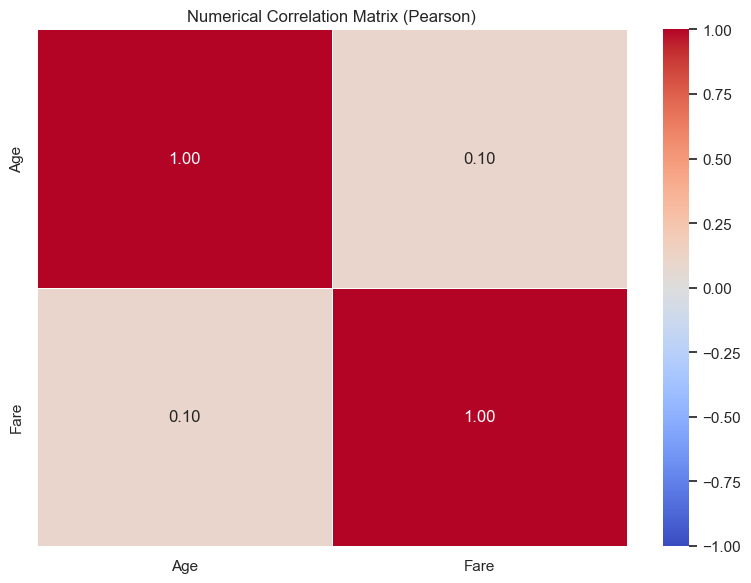

In [14]:
# 4. Correlation & Inline Visualizations

# Renders a joint correlation matrix heatmap across Age and Fare
eda.plot_correlation()

#### The Engine's Limitation & Traditional Next Step
It successfully isolated true continuous variables, but because `Survived` and `Pclass` were correctly extracted as `boolean` and `categorical` types earlier, they are excluded from this continuous Pearson correlation heatmap.
To traditionally evaluate the statistical associations between these categories and our numbers, we should write manual code

---Bivariate & Multivariate Analysis ---


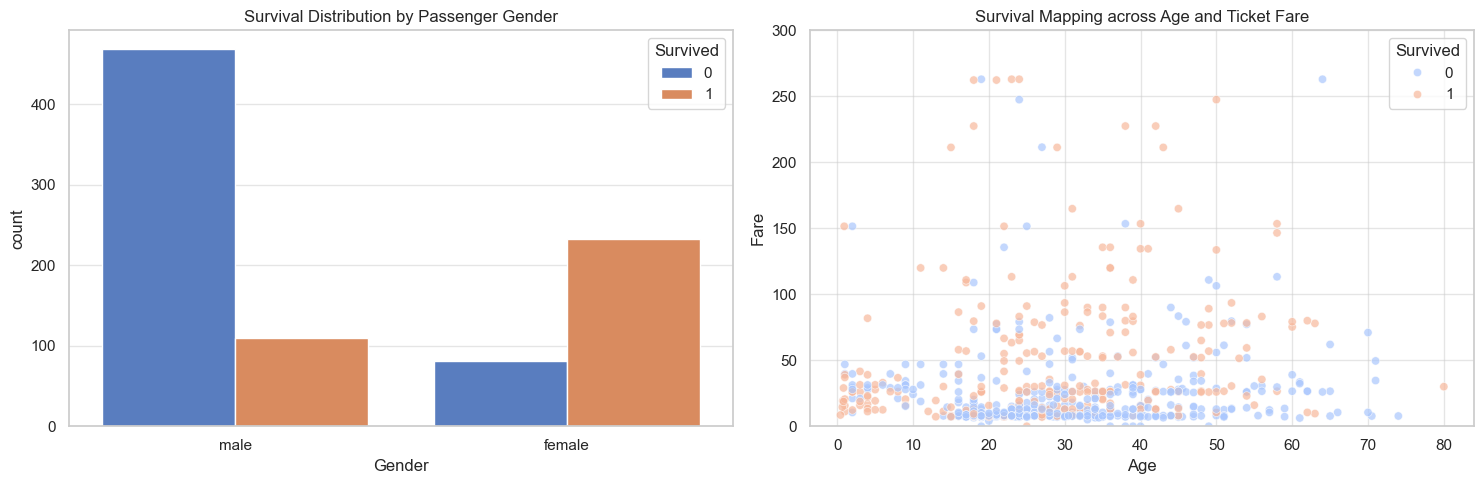

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

print("---Bivariate & Multivariate Analysis ---")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Survival Rates by Sex
sns.countplot(data=df, x="Sex", hue="Survived", palette="muted", ax=axes[0])
axes[0].set_title("Survival Distribution by Passenger Gender")
axes[0].set_xlabel("Gender")

# 2. Age vs Fare broken down by Survival
sns.scatterplot(data=df, x="Age", y="Fare", hue="Survived", alpha=0.7, palette="coolwarm", ax=axes[1])
axes[1].set_ylim(0, 300) # Capping y-axis to focus on the core cluster found by your profiler
axes[1].set_title("Survival Mapping across Age and Ticket Fare")

plt.tight_layout()
plt.show()

### Multivariate Analysis

we can immediately see the strong drivers behind passenger survival:

#### 1. The Gender Effect (The "Women and Children First" Protocol)
* **Male Passengers:** Despite making up nearly 65% of the passengers on board, the vast majority perished. Out of over 500 men, well under 150 survived.
* **Female Passengers:** Despite being a minority group in the dataset, females had an overwhelmingly high survival rate. Roughly **3 out of 4 women** survived the disaster.
* **Conclusion:** `Sex` is highly likely to be the single most powerful categorical feature for predictive modeling.

#### 2. (`Age` vs `Fare`)
* **The High-Fare Safety Zone:** The top section of the scatter plot (Fare > £100) represents the concentration of points shifts heavily to **orange dots (Survived)**. Passengers who purchased high-tier tickets had vastly superior survival odds, likely due to cabin locations closer to the lifeboat decks.
* **The Vulnerable Youth Cluster:** On the far left of the plot (Age < 10), we see a dense grouping of orange points spanning both low and moderate fares. This confirms that children were actively prioritized for rescue regardless of their ticket costs.
* **The Low-Fare Danger Zone:** The bottom-right quadrant (older passengers with lower fares) is heavily populated by **blue dots (Perished)**.